deepproblog - total :703 runs : 424 sets:279
NeurASP - total :705 runs : 425 sets:280
Run Agreement : (95.09%) 271/285
Set Agreement : (97.54%) 278/285
Total Agreement : (93.33%) 266/285
Time Taken : Deepproblog_Time: 3006.34seconds NeurASP_Time: 805.62 seconds 


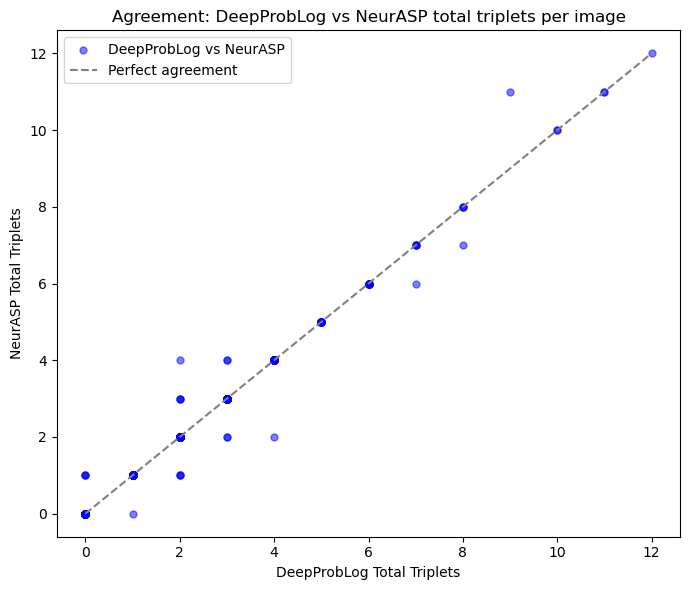

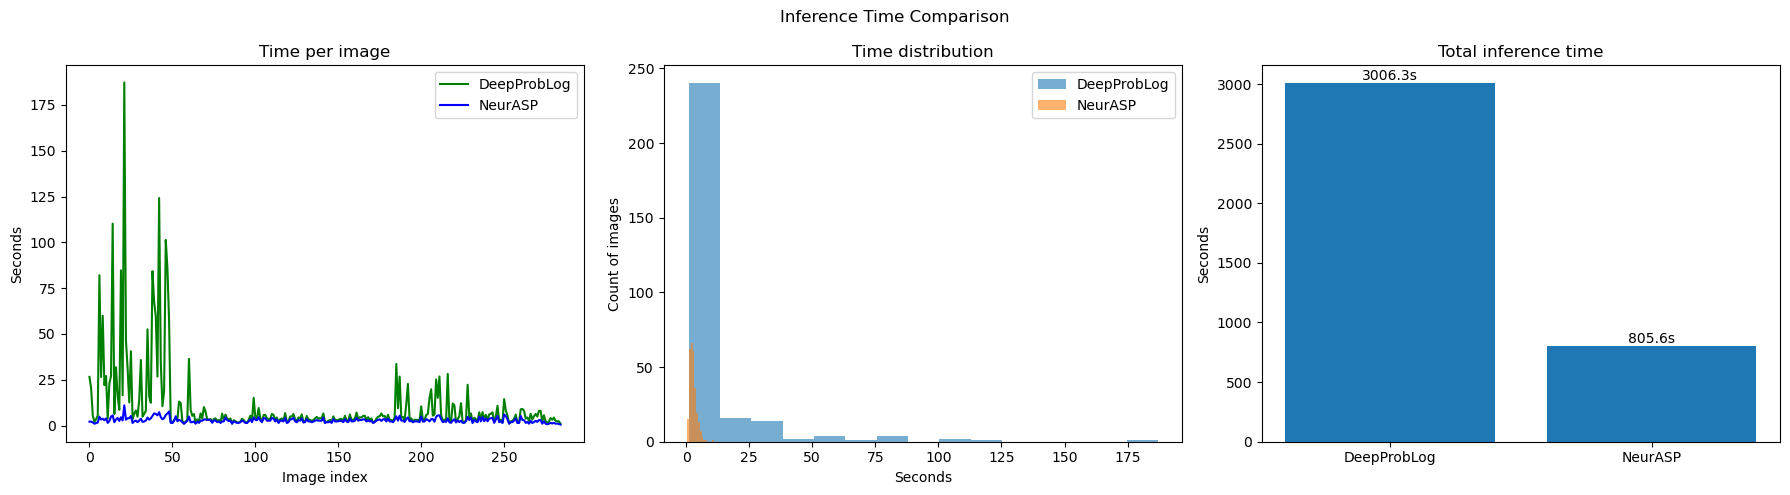

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import json
from scipy.stats import linregress
from matplotlib.ticker import MaxNLocator

with open("deepproblog_results.json") as file:
    data_dr = json.load(file)
    dlog = {x["image"]: x for x in data_dr["results"]}
    dlog_time = data_dr["total_time"]

with open("neurasp_results.json") as file2:
    data_nasp = json.load(file2)
    nasp = {x["image"]: x for x in data_nasp["results"]}
    nasp_time = data_nasp["total_time"]

images = sorted(set(dlog) & set(nasp))
len_n = len(images)
index = np.arange(len_n)

deepproblog_run = np.array([dlog[x]["n_valid_run"] for x in images])
deepproblog_set = np.array([dlog[x]["n_valid_set"] for x in images])
NeurASP_run     = np.array([nasp[x]["n_valid_run"] for x in images])
NeurASP_set     = np.array([nasp[x]["n_valid_set"] for x in images])

deepproblog_time = np.array([dlog[x].get("time_seconds", 0) for x in images])
NeurASP_time     = np.array([nasp[x].get("time_seconds", 0) for x in images])

deepproblog_total = deepproblog_run + deepproblog_set
NeurASP_total     = NeurASP_run     + NeurASP_set

dp_clusters = np.array([dlog[x]["num_clusters"] for x in images], dtype=float)
na_clusters = np.array([nasp[x]["num_clusters"] for x in images], dtype=float)

agreement_run   = len(np.where(deepproblog_run == NeurASP_run)[0])
agreement_set   = len(np.where(deepproblog_set == NeurASP_set)[0])
total_agreement = len(np.where(deepproblog_total == NeurASP_total)[0])

sum_deep     = deepproblog_total.sum()
sum_deep_run = deepproblog_run.sum()
sum_deep_set = deepproblog_set.sum()
sum_neur     = NeurASP_total.sum()
sum_neur_run = NeurASP_run.sum()
sum_neur_set = NeurASP_set.sum()

print(f"deepproblog - total :{sum_deep} runs : {sum_deep_run} sets:{sum_deep_set}")
print(f"NeurASP - total :{sum_neur} runs : {sum_neur_run} sets:{sum_neur_set}")
print(f"Run Agreement : ({agreement_run/len_n*100:.2f}%) {agreement_run}/{len_n}")
print(f"Set Agreement : ({agreement_set/len_n*100:.2f}%) {agreement_set}/{len_n}")
print(f"Total Agreement : ({total_agreement/len_n*100:.2f}%) {total_agreement}/{len_n}")
print(f"Time Taken : Deepproblog_Time: {dlog_time:.2f}seconds NeurASP_Time: {nasp_time:.2f} seconds ")


# ── Plot 1 — Scatter Plot: Per-image agreement ────────────────────────────────
fig1, ax_sc = plt.subplots(figsize=(7, 6))

ax_sc.scatter(deepproblog_total, NeurASP_total, color="blue",
              alpha=0.5, s=25, label="DeepProbLog vs NeurASP")
max_val = max(deepproblog_total.max(), NeurASP_total.max())
ax_sc.plot([0, max_val], [0, max_val], linestyle="--", color="gray",
           label="Perfect agreement")
ax_sc.set_title("Agreement: DeepProbLog vs NeurASP total triplets per image")
ax_sc.set_xlabel("DeepProbLog Total Triplets")
ax_sc.set_ylabel("NeurASP Total Triplets")
ax_sc.legend()
plt.tight_layout()
plt.show()


# ── Plot 2 — Inference Time (3-panel) ────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Inference Time Comparison")

axes2[0].plot(deepproblog_time, label="DeepProbLog", color="Green")
axes2[0].plot(NeurASP_time,     label="NeurASP",     color="Blue")
axes2[0].set_title("Time per image")
axes2[0].set_xlabel("Image index")
axes2[0].set_ylabel("Seconds")
axes2[0].legend()

axes2[1].hist(deepproblog_time, bins=15, alpha=0.6, label="DeepProbLog")
axes2[1].hist(NeurASP_time,     bins=15, alpha=0.6, label="NeurASP")
axes2[1].set_title("Time distribution")
axes2[1].set_xlabel("Seconds")
axes2[1].set_ylabel("Count of images")
axes2[1].legend()

times  = [dlog_time, nasp_time]
labels = ["DeepProbLog", "NeurASP"]
axes2[2].bar(labels, times)
for i, t in enumerate(times):
    axes2[2].text(i, t, f"{t:.1f}s", ha="center", va="bottom")
axes2[2].set_title("Total inference time")
axes2[2].set_ylabel("Seconds")

plt.tight_layout()
plt.show()

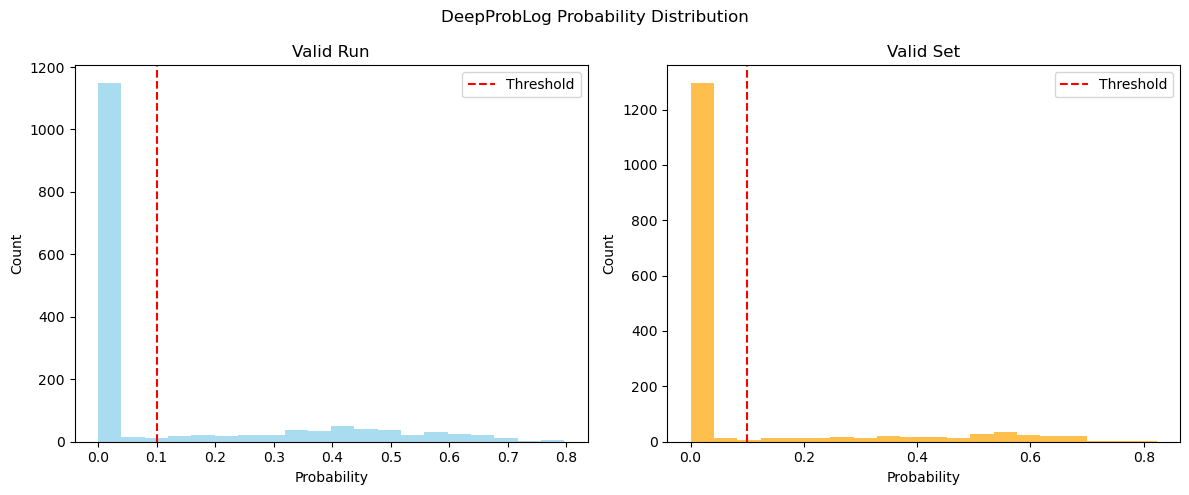

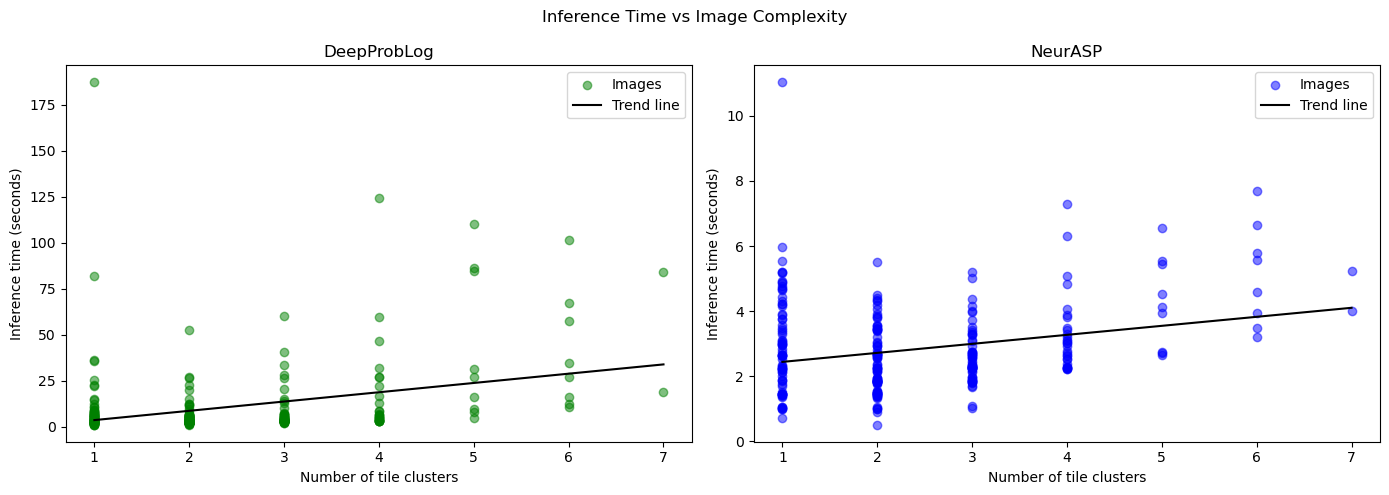

In [4]:
# Collect all probabilities
all_run_probs = []
all_set_probs = []

for entry in data_dr["results"]:
    all_run_probs.extend(entry.get("all_run_probs", []))
    all_set_probs.extend(entry.get("all_set_probs", []))
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle("DeepProbLog Probability Distribution")
axes3[0].hist(all_run_probs, bins=20, color="skyblue", alpha=0.7)
axes3[0].axvline(0.10, color="red", linestyle="--", label="Threshold")
axes3[0].set_title("Valid Run")
axes3[0].set_xlabel("Probability")
axes3[0].set_ylabel("Count")
axes3[0].legend()
axes3[1].hist(all_set_probs, bins=20, color="orange", alpha=0.7)
axes3[1].axvline(0.10, color="red", linestyle="--", label="Threshold")
axes3[1].set_title("Valid Set")
axes3[1].set_xlabel("Probability")
axes3[1].set_ylabel("Count")
axes3[1].legend()

plt.tight_layout()
plt.show()

from scipy.stats import linregress
def trend(x, y):
    slope, intercept, _, _, _ = linregress(x, y)
    x_line = np.linspace(min(x), max(x), 100)
    y_line = slope * x_line + intercept
    return x_line, y_line

# Get trend lines
dp_x, dp_y = trend(dp_clusters, deepproblog_time)
na_x, na_y = trend(na_clusters, NeurASP_time)

fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle("Inference Time vs Image Complexity")

axes4[0].scatter(dp_clusters, deepproblog_time,
                 color="green", alpha=0.5, label="Images")
axes4[0].plot(dp_x, dp_y,
              color="black", label="Trend line")
axes4[0].set_title("DeepProbLog")
axes4[0].set_xlabel("Number of tile clusters")
axes4[0].set_ylabel("Inference time (seconds)")
axes4[0].legend()

axes4[1].scatter(na_clusters, NeurASP_time,
                 color="blue", alpha=0.5, label="Images")
axes4[1].plot(na_x, na_y,
              color="black", label="Trend line")
axes4[1].set_title("NeurASP")
axes4[1].set_xlabel("Number of tile clusters")
axes4[1].set_ylabel("Inference time (seconds)")
axes4[1].legend()

plt.tight_layout()
plt.show()